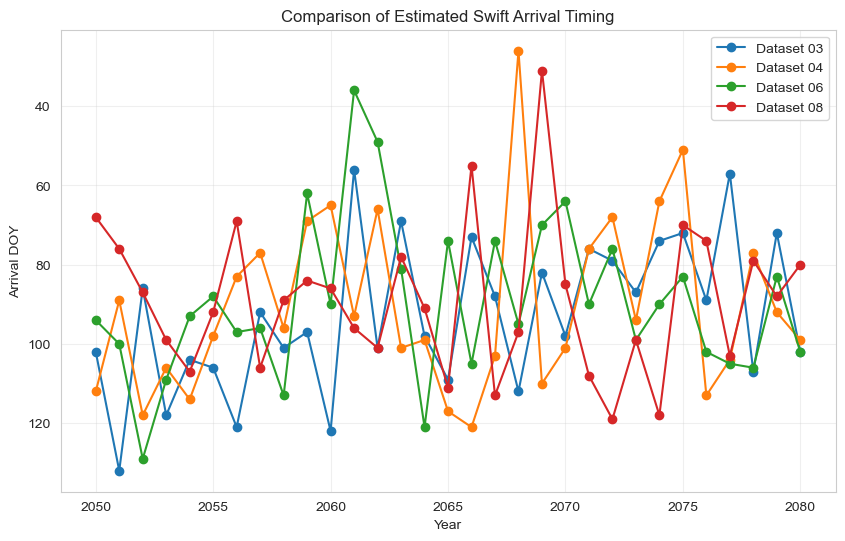

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# read predict dataset
datasets = {
    "03": pd.read_csv("dataset_03_predictions.csv"),
    "04": pd.read_csv("dataset_04_predictions.csv"),
    "06": pd.read_csv("dataset_06_predictions.csv"),
    "08": pd.read_csv("dataset_08_predictions.csv")
}

#define the arrival day
def compute_arrival(df, threshold=15):
    df["time"] = pd.to_datetime(df["time"])
    df = df.sort_values("time").reset_index(drop=True)


    df["Tmax_pred"] = df["prediction"]

    # ≥ threshold
    df["warm"] = df["Tmax_pred"] >= threshold


    df["warm_3day"] = (
        df["warm"] &
        df["warm"].shift(1) &
        df["warm"].shift(2)
    )


    arrival = (
        df[df["warm_3day"]]
        .groupby("year")["dayofyear"]
        .min()
        .reset_index()
    )

    arrival.rename(columns={"dayofyear": "Arrival_DOY"}, inplace=True)

    return arrival


#result
results = {}

for name, df in datasets.items():
    results[name] = compute_arrival(df)



plt.figure(figsize=(10,6))

for name, df in results.items():
    plt.plot(df["year"], df["Arrival_DOY"], marker='o', label=f"Dataset {name}")


plt.xlabel("Year")
plt.ylabel("Arrival DOY")
plt.title("Comparison of Estimated Swift Arrival Timing")

plt.gca().invert_yaxis()
plt.legend()
plt.grid(alpha=0.3)

plt.show()

/var/folders/43/sc0rs7n13pn7125_42784cgc0000gn/T/ipykernel_50130/1376695893.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels)


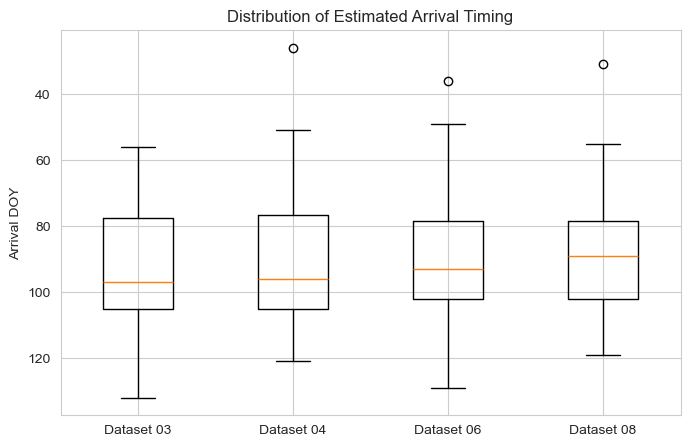

In [3]:
import matplotlib.pyplot as plt


data = [df["Arrival_DOY"] for df in results.values()]
labels = [f"Dataset {k}" for k in results.keys()]

plt.figure(figsize=(8,5))
plt.boxplot(data, labels=labels)

plt.ylabel("Arrival DOY")
plt.title("Distribution of Estimated Arrival Timing")

plt.gca().invert_yaxis()

plt.show()

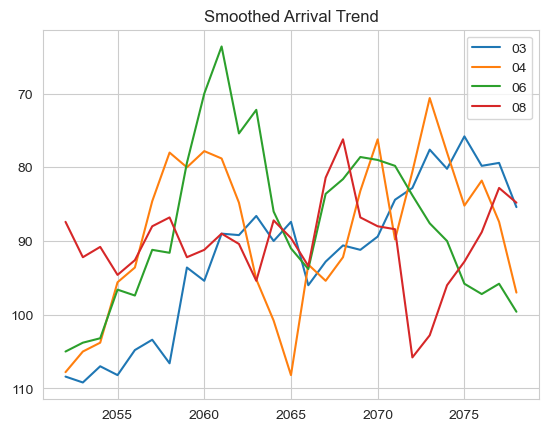

In [4]:
for name, df in results.items():
    df["smooth"] = df["Arrival_DOY"].rolling(5, center=True).mean()

    plt.plot(df["year"], df["smooth"], label=f"{name}")

plt.gca().invert_yaxis()
plt.legend()
plt.title("Smoothed Arrival Trend")

plt.show()